<a href="https://colab.research.google.com/github/octavio-cardona-g/cv-anomaly-detection/blob/main/cv_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cloning repo in Google Colab, installing dependencias, and downloading data

In [ ]:
!git clone https://github.com/octavio-cardona-g/cv-anomaly-detection.git
%cd cv-anomaly-detection

fatal: destination path 'cv-anomaly-detection' already exists and is not an empty directory.
/content/cv-anomaly-detection


In [ ]:
!pip install -q scikit.learn opencv-python-headless kagglehub

"""matplotlib, numpy, and tensorflow are already present in Colab
 by default — no need to install them. kagglehub will help with the next step,
 since MVTec AD is mirrored on Kaggle and easier to pull that way than
 the original site's form-gated download."""

"matplotlib, numpy, and tensorflow are already present in Colab\n by default — no need to install them. kagglehub will help with the next step,\n since MVTec AD is mirrored on Kaggle and easier to pull that way than\n the original site's form-gated download."

In [ ]:
import json
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from sklearn.metrics import roc_auc_score
import tensorflow as tf
import numpy as np
import pickle
import kagglehub
import os
import cv2

In [ ]:
path = kagglehub.dataset_download("ipythonx/mvtec-ad")
print(path)

Using Colab cache for faster access to the 'mvtec-ad' dataset.
/kaggle/input/mvtec-ad


In [ ]:
bottle_path = os.path.join(path, "bottle") #For now we will focus only on the bottle dataset
print(os.listdir(bottle_path))

['readme.txt', 'ground_truth', 'license.txt', 'test', 'train']


# Exploring bottle data

In [ ]:
train_good = os.path.join(bottle_path, "train", "good")
test_dir = os.path.join(bottle_path, "test")

print("Train (good only):", os.listdir(train_good)[:5], "... total:", len(os.listdir(train_good)))
print("Test categories:", os.listdir(test_dir))

Train (good only): ['173.png', '043.png', '038.png', '069.png', '083.png'] ... total: 209
Test categories: ['good', 'contamination', 'broken_large', 'broken_small']


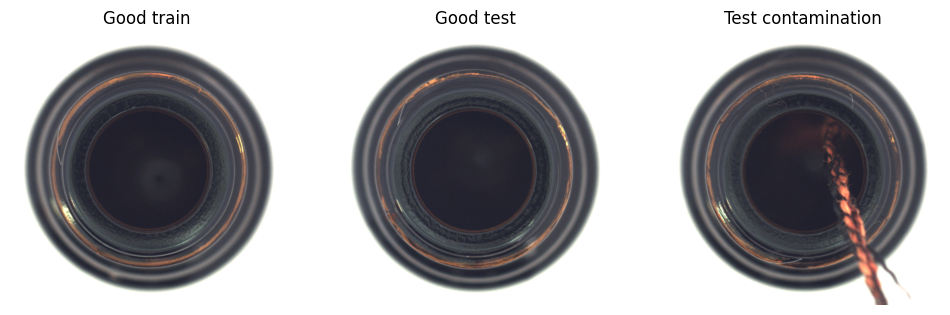

In [ ]:
defect_types = [d for d in os.listdir(test_dir) if d != "good"]
sample_defect = defect_types[0]

img_good_train = Image.open(os.path.join(train_good, os.listdir(train_good)[0]))
img_good_test = Image.open(os.path.join(test_dir, "good", os.listdir(os.path.join(test_dir, "good"))[0]))
img_defect = Image.open(os.path.join(test_dir, sample_defect, os.listdir(os.path.join(test_dir, sample_defect))[0]))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes, [img_good_train, img_good_test, img_defect], ["Good train", "Good test", f"Test {sample_defect}"]):
  ax.imshow(img)
  ax.set_title(title)
  ax.axis("off")
plt.show()

# Building a baseline convolutional autoencoder

In [ ]:
IMG_SIZE = 128

def load_images(folder, size=IMG_SIZE):
  paths = [os.path.join(folder, f) for f in os.listdir(folder)]
  images = []
  for p in paths:
    img = tf.keras.utils.load_img(p, target_size=(size, size))
    images.append(tf.keras.utils.img_to_array(img))
  return np.array(images), paths

X_train, _ = load_images(train_good)
X_train = X_train / 255.0
print("Train shape:", X_train.shape)

Train shape: (209, 128, 128, 3)


In [ ]:
#Convolutional autoencoder architecture

tf.random.set_seed(42)

conv_encoder =  tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(60, 3, padding="same", activation="relu")
])

conv_decoder = tf.keras.Sequential([
    tf.keras.layers.Conv2DTranspose(64, 3, strides=2 , padding="same",
                                    activation="relu"),
    tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding="same",
                                    activation="relu"),
    tf.keras.layers.Conv2DTranspose(3, 3, strides=2, padding="same",
                                    activation="sigmoid"),
])



In [ ]:
conv_ae = tf.keras.Sequential([conv_encoder, conv_decoder])
conv_ae.compile(loss="mse", optimizer=tf.keras.optimizers.Nadam())


In [ ]:
sample_output = conv_ae.predict(X_train[:1])
print(sample_output.min(), sample_output.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
0.48654088 0.5101871


In [ ]:
history = conv_ae.fit(X_train, X_train, epochs=10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 690ms/step - loss: 0.1307
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1157
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0920
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0698
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0568
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0467
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0345
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0256
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0200
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0158


# Testing the model on a good and defective images

In [ ]:
X_test_good, _ = load_images(os.path.join(test_dir, "good"))
X_test_good = X_test_good / 255.0
print("Test shape:", X_test_good.shape)

Test shape: (20, 128, 128, 3)


In [ ]:
X_test_defect, _ = load_images(os.path.join(test_dir, sample_defect))
X_test_defect = X_test_defect / 255.0
print("Test shape:", X_test_defect.shape)

Test shape: (21, 128, 128, 3)


In [ ]:
#Estimating the reconstruction error per pixel on a good image

X_test_predict = conv_ae.predict(X_test_good[0:1])
error_pixel = np.power(X_test_good[0] - X_test_predict[0], 2)
mse = np.mean(error_pixel, axis=(1, 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [ ]:
#Estimating the reconstruction error per pixel on a defect image
X_test_defect_predict = conv_ae.predict(X_test_defect[0:1])
error_pixel_defect = np.power(X_test_defect[0] - X_test_defect_predict[0], 2)
mse_defect = np.mean(error_pixel_defect, axis=(1, 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


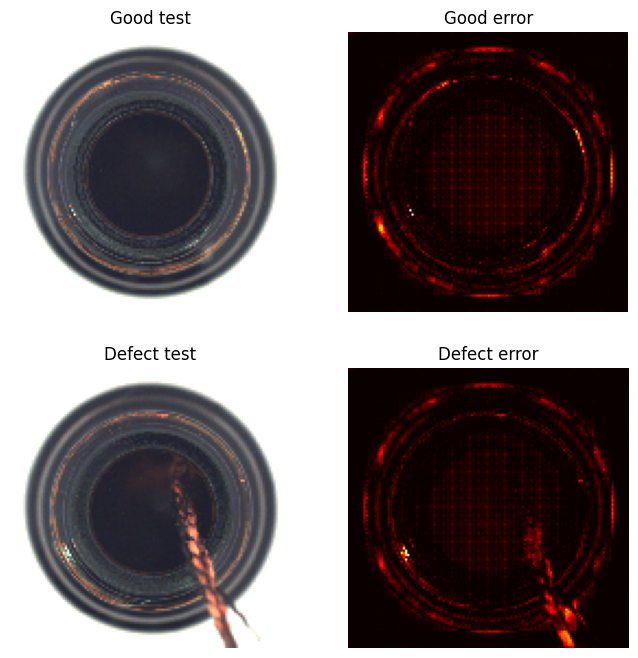

In [ ]:
#Plotting both error heatmaps to compare

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
images_to_plot = [
    X_test_good[0], np.mean(error_pixel, axis=-1),
    X_test_defect[0], np.mean(error_pixel_defect, axis=-1)
]
titles = ["Good test", "Good error", "Defect test", "Defect error"]

for i, (ax, img, title) in enumerate(zip(axes.flatten(), images_to_plot, titles)):
  if "error" in title: # Apply heatmap cmap for error plots
    ax.imshow(img, cmap='hot')
  else: # For original images
    ax.imshow(img)
  ax.set_title(title)
  ax.axis("off")
plt.show()

In [ ]:
#Finding the error per pixel off all test images and comparing
#the mean over all pixels, and mean of the top-k% highest-error

all_test_image_files = []
for category_folder in os.listdir(test_dir):
    category_path = os.path.join(test_dir, category_folder)
    if os.path.isdir(category_path):
        for img_file_name in os.listdir(category_path):
            if img_file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_test_image_files.append(os.path.join(category_path, img_file_name))


X_test_list = []
for img_path in all_test_image_files:
    img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    X_test_list.append(tf.keras.utils.img_to_array(img))

X_test = np.array(X_test_list)
X_test = X_test / 255.0
X_test_predict_all = conv_ae.predict(X_test)

error_pixel_all = np.power(X_test - X_test_predict_all, 2)
error_pixel_mean = np.mean(error_pixel_all, axis=-1) # Mean across color channels
error_mean = np.mean(error_pixel_mean, axis=(1,2)) # Mean across all pixels per image
error_pixel_mean_flat = error_pixel_mean.reshape(83,128*128) #83 images
k = round(128**2 * 0.05) #Number equivalent to 5%
error_topk_mean = np.mean(np.sort(error_pixel_mean_flat, axis=1)[:, -k:], axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 326ms/step


In [ ]:
#Building histogams per catetgory

category_number = [0]
for category_folder in os.listdir(test_dir):
    category_number.append(len(os.listdir(os.path.join(test_dir, category_folder))))
category_number_cumsum = np.cumsum(category_number)
test_categories = list(os.listdir(test_dir))

def build_hist(x, test_categories=test_categories, category_number=category_number_cumsum):
    fig, ax = plt.subplots(4, 1, figsize=(10, 14))
    n_bins = 5


    global_min = np.min(x)
    global_max = np.max(x)
    shared_bins = np.linspace(global_min, global_max, num=n_bins + 1)

    for i in range(len(category_number)-1):

        category_data = x[category_number[i]:category_number[i+1]]


        ax[i].hist(category_data, bins=shared_bins, edgecolor='k')
        ax[i].set_title(test_categories[i])


        mean_val = np.mean(category_data)
        label = test_categories[i]


        ax[i].axvline(mean_val, color='r', linestyle='dashed', linewidth=1.5,
                    label=f'Media: {mean_val:.2f}')


        ax[i].set_xlim(global_min, global_max)


        ax[i].legend(loc='upper right')

    plt.tight_layout()
    plt.show()



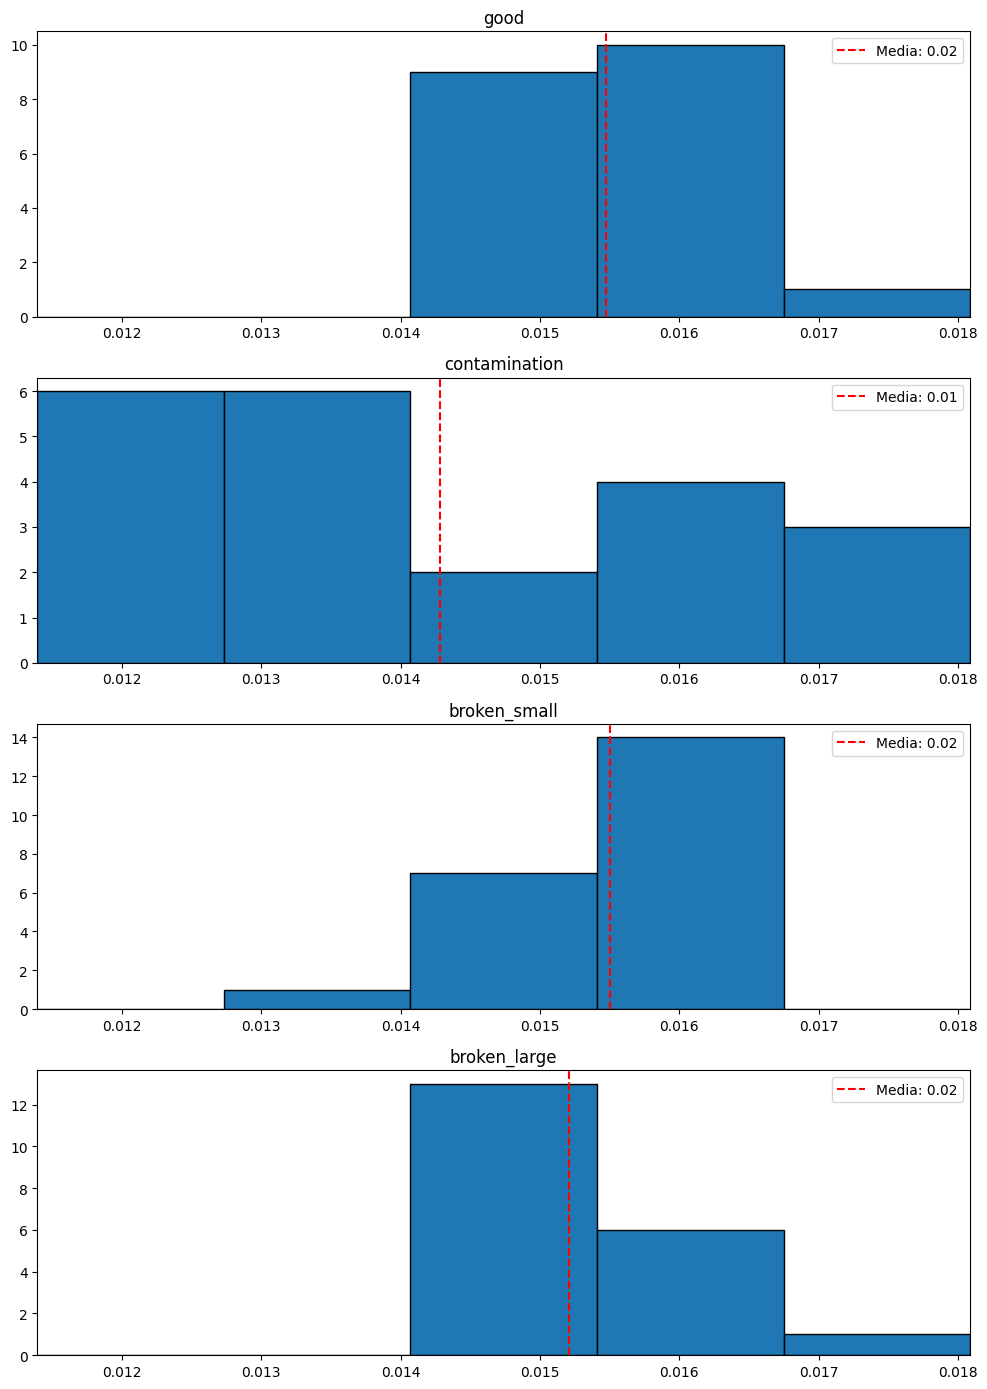

In [ ]:
#Histogram for overall mean
build_hist(error_mean)

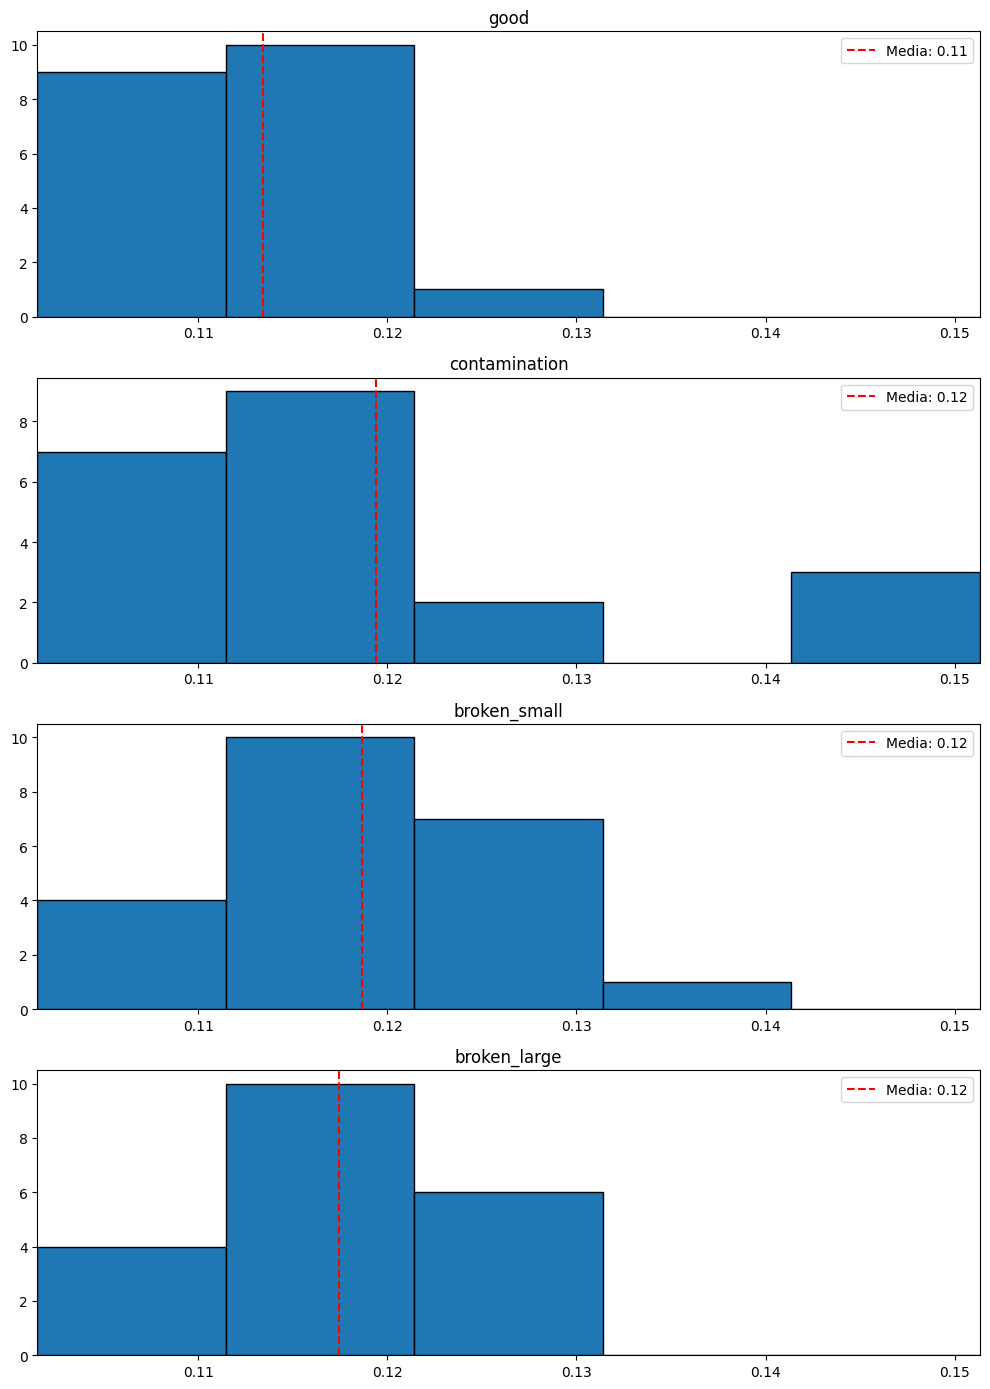

In [ ]:
#Histogram for top 5% highest errors mean
build_hist(error_topk_mean)

In [ ]:
all_categories_flat = []
for category, count in zip(test_categories, category_number[1:]):
    all_categories_flat.extend([category] * count)

print(all_categories_flat[:5])
print(f"Total items in the new list: {len(all_categories_flat)}")

['good', 'good', 'good', 'good', 'good']
Total items in the new list: 83


In [ ]:
error_mean_label = zip(error_mean, all_categories_flat)
error_topk_mean_label = zip(error_topk_mean, all_categories_flat)

In [ ]:
def compute_auroc(category_list, score_list):

  results = {}
  df = pd.DataFrame(zip(category_list, score_list))
  df.columns = ["category", "score"]
  df["y_true"] = df["category"].apply(lambda x: 0 if x == "good" else 1)


  results["combined"] = roc_auc_score(df["y_true"], df["score"])

  for category in test_categories:
    if category != "good":
      df_score = df[df["category"].isin([category, "good"])]
      #print(df_score)
      results[category] = (roc_auc_score(df_score["y_true"], df_score["score"]))

  return results


In [ ]:
compute_auroc(all_categories_flat, error_mean)

{'combined': np.float64(0.40555555555555556),
 'contamination': np.float64(0.29047619047619044),
 'broken_small': np.float64(0.5431818181818182),
 'broken_large': np.float64(0.375)}

In [ ]:
compute_auroc(all_categories_flat, error_topk_mean)

{'combined': np.float64(0.6674603174603174),
 'contamination': np.float64(0.6047619047619047),
 'broken_small': np.float64(0.7181818181818183),
 'broken_large': np.float64(0.6775)}

Several numbers are below 0.5 we need to investigate if the model is performing poorly or there are error in the transformation pipeline.

In [ ]:
#Finding visual insights on high error "good" images and low error "contamination" images

X_test_good = X_test[:category_number[1]]
error_pixel_good = error_pixel_all[:category_number[1]]
error_mean_good = error_mean[:category_number[1]]
error_topk_mean_good = error_topk_mean[:category_number[1]]

sorted_idx = np.argsort(error_mean_good)
highest_good_idx = sorted_idx[-3:]
sorted_idx_topk = np.argsort(error_topk_mean_good)
highest_good_topk_idx = sorted_idx_topk[-3:]

X_test_contamination = X_test[category_number_cumsum[1]:category_number_cumsum[2]]
error_pixel_contamination = error_pixel_all[category_number_cumsum[1]:category_number_cumsum[2]]
error_mean_contamination = error_mean[category_number_cumsum[1]:category_number_cumsum[2]]
error_topk_mean_contamination = error_topk_mean[category_number_cumsum[1]:category_number_cumsum[2]]

sorted_idx_contamination = np.argsort(error_mean_contamination)
lowest_contamination_idx = sorted_idx_contamination[:3]
sorted_idx_topk_contamination = np.argsort(error_topk_mean_contamination)
lowest_contamination_topk_idx = sorted_idx_topk_contamination[:3]

X_test_good_highest_error = X_test_good[highest_good_idx]
X_predict_good_highest_error = X_test_predict_all[highest_good_idx]
error_pixel_good_highest_error = error_pixel_good[highest_good_idx]

X_test_contamination_lowest_error = X_test_contamination[lowest_contamination_idx]
X_predict_contamination_lowest_error = X_test_predict_all[lowest_contamination_idx]
error_pixel_contamination_lowest_error = error_pixel_contamination[lowest_contamination_idx]


In [ ]:
X_predict_good_highest_error.shape

(3, 128, 128, 3)

In [ ]:
print(highest_good_idx)
print(highest_good_topk_idx)

[ 1 10 14]
[ 7 10 14]


In [ ]:
print(lowest_contamination_idx)
print(lowest_contamination_topk_idx)

[17 11  3]
[12 17  5]


In [ ]:
def plot_error_map(img_array, error_array, reconstruction_array=None, type=None):
  # Plotting "good" bottles with the highest estimation error
  # Plotting "good" bottles error map
  fig, axes = plt.subplots(3, 3, figsize=(12, 8))

  # Calculate the mean error map across color channels for plotting
  error_map_good_highest_error = np.mean(error_array, axis=-1)

  if reconstruction_array is None:
    for i in range(3):
      # Plot the original image in the first row
      axes[0, i].imshow(img_array[i])
      axes[0, i].set_title(f"{type} {i+1}")
      axes[0, i].axis("off")

      # Plot the corresponding error map in the second row
      axes[1, i].imshow(error_map_good_highest_error[i], cmap='hot')
      axes[1, i].set_title(f"{type} error {i+1}")
      axes[1, i].axis("off")

  else:
      for i in range(3):
        # Plot the original image in the first row
       axes[0, i].imshow(img_array[i])
       axes[0, i].set_title(f"{type} {i+1}")
       axes[0, i].axis("off")

        # Plot the reconstruction image in the second row
       axes[1, i].imshow(reconstruction_array[i])
       axes[1, i].set_title(f"{type} reconstruction {i+1}")
       axes[1, i].axis("off")

        # Plot the corresponding error map in the third row
       axes[2, i].imshow(error_map_good_highest_error[i], cmap='hot')
       axes[2, i].set_title(f"{type} error {i+1}")
       axes[2, i].axis("off")

  plt.tight_layout() # Adjusting layout to prevent overlap
  plt.show()

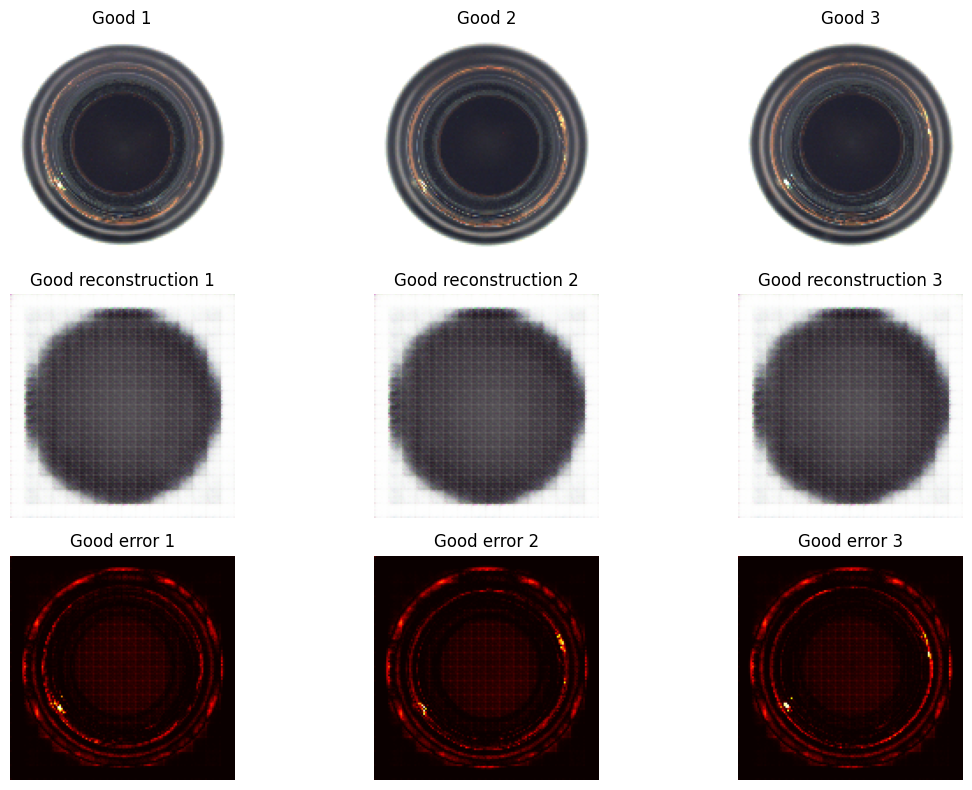

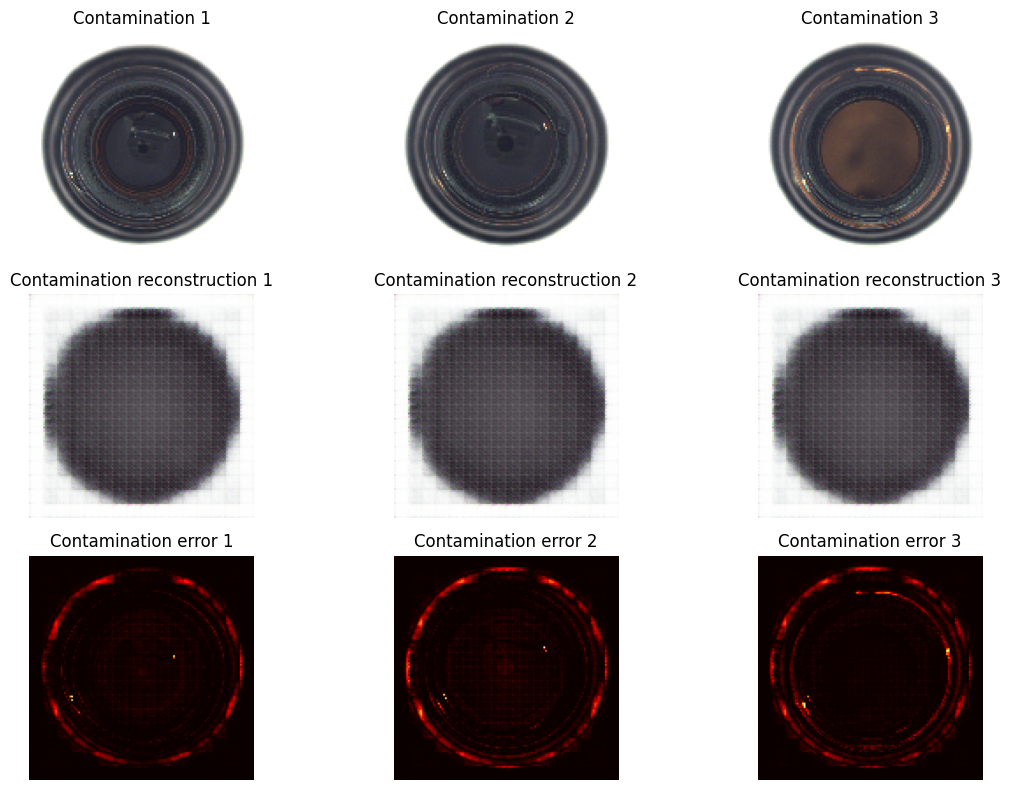

In [ ]:
#Plotting good bottles with high error and contaminated bottles with low error
plot_error_map(X_test_good_highest_error, error_pixel_good_highest_error, X_predict_good_highest_error, "Good")
plot_error_map(X_test_contamination_lowest_error, error_pixel_contamination_lowest_error, X_predict_contamination_lowest_error, "Contamination")


The model does not seem to be learning, thus we'll increase the number of epochs and if it does not work, change the architecture.

In [ ]:
#saving previous history

#old_history = history.history

#cleaning memomry
tf.keras.backend.clear_session()
tf.random.set_seed(42)

#Building and training the model for a longer period
conv_encoder =  tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(60, 3, padding="same", activation="relu")
])

conv_decoder = tf.keras.Sequential([
    tf.keras.layers.Conv2DTranspose(128, 3, strides=2 , padding="same",
                                    activation="relu"),
    tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same",
                                    activation="relu"),
    tf.keras.layers.Conv2DTranspose(3, 3, strides=2, padding="same",
                                    activation="sigmoid"),
])

conv_ae = tf.keras.Sequential([conv_encoder, conv_decoder])
conv_ae.compile(loss="mse", optimizer=tf.keras.optimizers.Nadam())

#setting early stop
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

#training new model for more epochs
history = conv_ae.fit(X_train, X_train, epochs=100, callbacks=[early_stopping_cb])

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 411ms/step - loss: 0.1281
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1077
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0790
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0628
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0457
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0297
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0200
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0139
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0103
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0090
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0062
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0072
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0054
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0043
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0039
Epoch 16/100
7/7 ━

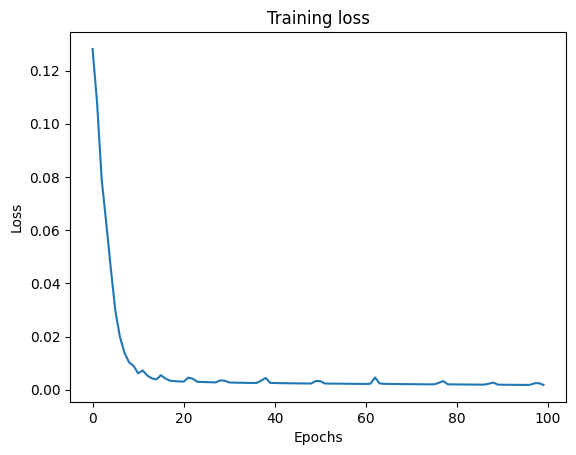

In [ ]:
#plotting loss curve

plt.plot(history.history["loss"], label="Training loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

In [ ]:
X_test_predict_all = conv_ae.predict(X_test)

X_test_good_highest_error = X_test_good[highest_good_idx]
X_predict_good_highest_error = X_test_predict_all[highest_good_idx]
error_pixel_good_highest_error = error_pixel_good[highest_good_idx]

X_test_contamination_lowest_error = X_test_contamination[lowest_contamination_idx]
X_predict_contamination_lowest_error = X_test_predict_all[lowest_contamination_idx]
error_pixel_contamination_lowest_error = error_pixel_contamination[lowest_contamination_idx]


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step


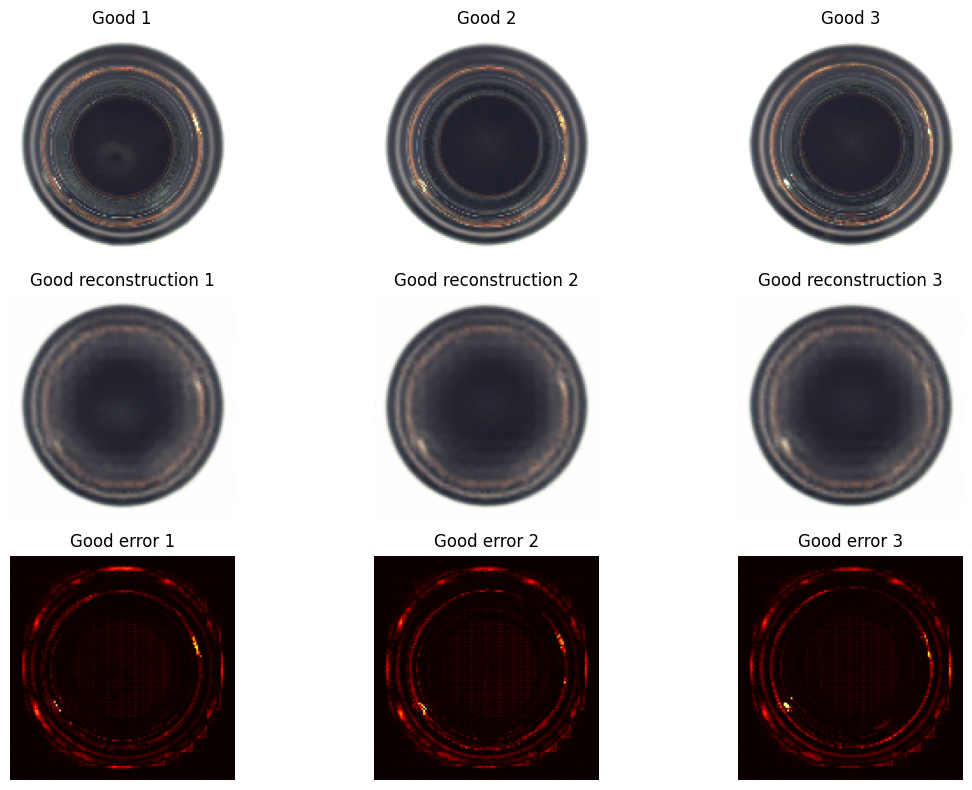

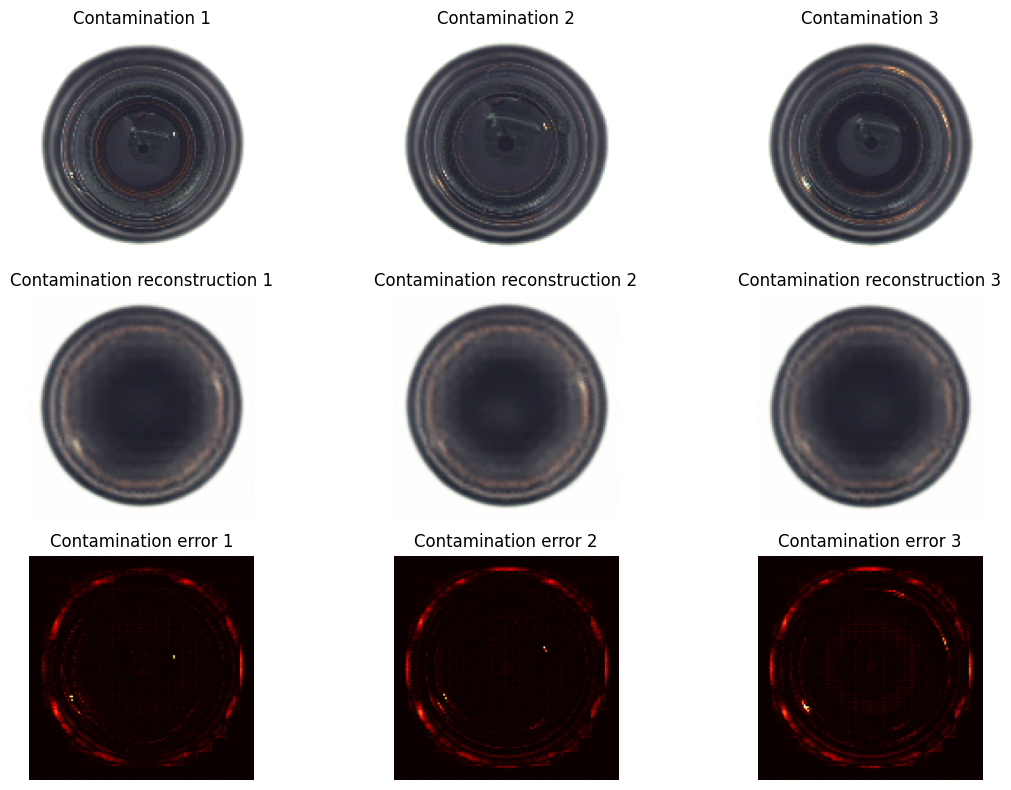

In [ ]:
#Plotting good bottles with high error and contaminated bottles with low error
plot_error_map(X_test_good_highest_error, X_predict_good_highest_error, error_pixel_good_highest_error, "Good")
plot_error_map(X_test_contamination_lowest_error, X_predict_contamination_lowest_error, error_pixel_contamination_lowest_error, "Contamination")

The recostructions look much better, but they are still low quality, we can change the architecture to avoid convergence to the average.

# Changing the architecture for better fit

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

conv_encoder = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=2),        # 64x64

    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=2),        # 32x32

    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=2),        # 16x16

    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
])

conv_decoder = tf.keras.Sequential([
    tf.keras.layers.UpSampling2D(size=2),          # 32x32
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.UpSampling2D(size=2),          # 64x64
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.UpSampling2D(size=2),          # 128x128
    tf.keras.layers.Conv2D(3, 3, padding="same", activation="sigmoid"),
])

conv_ae = tf.keras.Sequential([conv_encoder, conv_decoder])
conv_ae.compile(loss="mse", optimizer=tf.keras.optimizers.Nadam())

history = conv_ae.fit(X_train, X_train, epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 0.0592
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 0.0131
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0097
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0082
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0073
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0066
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0060
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0055
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0050
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0046
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0042
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0038
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0035
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0033
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0031
Epoch 16/100
7/7 ━━━

In [ ]:
X_test_predict_all = conv_ae.predict(X_test)

X_test_good_highest_error = X_test_good[highest_good_idx]
X_predict_good_highest_error = X_test_predict_all[highest_good_idx]
error_pixel_good_highest_error = error_pixel_good[highest_good_idx]

X_test_contamination_lowest_error = X_test_contamination[lowest_contamination_idx]
X_predict_contamination_lowest_error = X_test_predict_all[lowest_contamination_idx]
error_pixel_contamination_lowest_error = error_pixel_contamination[lowest_contamination_idx]

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 557ms/step


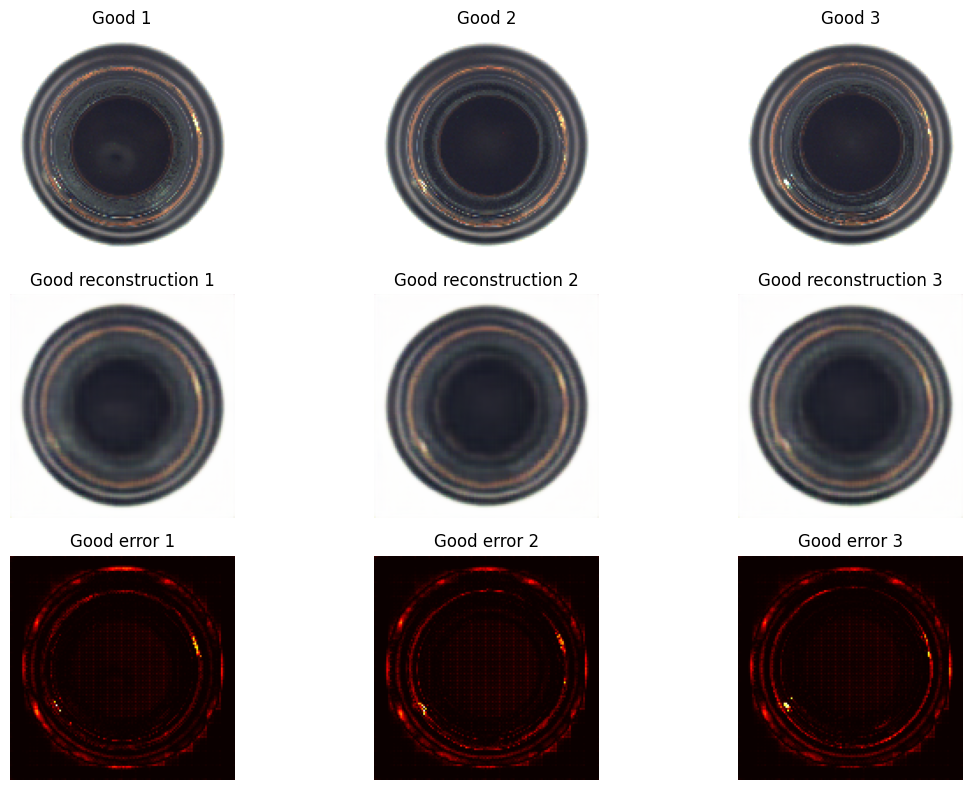

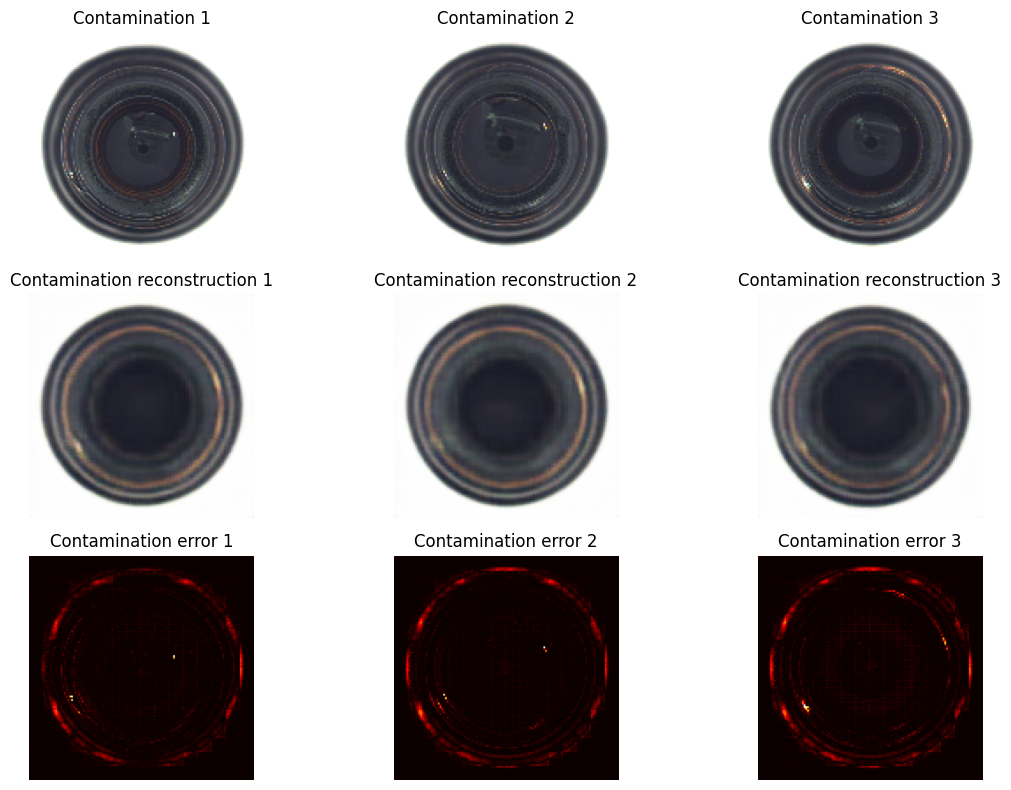

In [ ]:
#Plotting good bottles with high error and contaminated bottles with low error
plot_error_map(X_test_good_highest_error, X_predict_good_highest_error, error_pixel_good_highest_error, "Good")
plot_error_map(X_test_contamination_lowest_error, X_predict_contamination_lowest_error, error_pixel_contamination_lowest_error, "Contamination")

In [ ]:
#Computing AUROC for the new model:

error_pixel_all = np.power(X_test - X_test_predict_all, 2)
error_pixel_mean = np.mean(error_pixel_all, axis=-1) # Mean across color channels
error_mean = np.mean(error_pixel_mean, axis=(1,2)) # Mean across all pixels per image
error_pixel_mean_flat = error_pixel_mean.reshape(83,128*128) #83 images
k = round(128**2 * 0.05) #Number equivalent to 5%
error_topk_mean = np.mean(np.sort(error_pixel_mean_flat, axis=1)[:, -k:], axis=1)

In [ ]:
compute_auroc(all_categories_flat, error_mean)

{'combined': np.float64(0.8301587301587301),
 'contamination': np.float64(0.7190476190476189),
 'broken_large': np.float64(0.9225),
 'broken_small': np.float64(0.8522727272727273)}

In [ ]:
compute_auroc(all_categories_flat, error_topk_mean)

{'combined': np.float64(0.8206349206349206),
 'contamination': np.float64(0.6452380952380952),
 'broken_large': np.float64(0.9299999999999999),
 'broken_small': np.float64(0.8886363636363637)}

New new AUROC are more stronger as before and we saw the images now can reconstruct the images better. Let's save the model and results as a baseline

In [ ]:
# Saving the trained model
conv_ae.save("autoencoder_bottle.keras")

# Saving training history
with open("training_history.json", "w") as f:
    json.dump(history.history, f)

# Saving AUROC results
results = {
    "mean_score_auroc": {k: float(v) for k, v in compute_auroc(all_categories_flat, error_mean).items()},
    "topk_score_auroc": {k: float(v) for k, v in compute_auroc(all_categories_flat, error_topk_mean).items()},
}
with open("baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)

#PatchCore model

Let's start with a smaller model that would serve as a baseline. The idea is to identify the middle layers that contain enough structure to recognize patterns in the contaminated bottles without losing precision in the ones with defects.

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.neighbors import NearestNeighbors

backbone_full = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)

for layer in backbone_full.layers:
  print(layer.name)

input_layer_3
conv1_pad
conv1_conv
conv1_bn
conv1_relu
pool1_pad
pool1_pool
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_2_bn
conv2_block1_2_relu
conv2_block1_0_conv
conv2_block1_3_conv
conv2_block1_0_bn
conv2_block1_3_bn
conv2_block1_add
conv2_block1_out
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_2_bn
conv2_block2_2_relu
conv2_block2_3_conv
conv2_block2_3_bn
conv2_block2_add
conv2_block2_out
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_2_bn
conv2_block3_2_relu
conv2_block3_3_conv
conv2_block3_3_bn
conv2_block3_add
conv2_block3_out
conv3_block1_1_conv
conv3_block1_1_bn
conv3_block1_1_relu
conv3_block1_2_conv
conv3_block1_2_bn
conv3_block1_2_relu
conv3_block1_0_conv
conv3_block1_3_conv
conv3_block1_0_bn
conv3_block1_3_bn
conv3_block1_add
conv3_block1_out
conv3_block2_1_conv
conv3_block2_1_bn
conv3_block2_1_relu
conv3_block2_2_conv
conv3_block2_2_bn


In [ ]:
#Let's freeze after conv3_block4_out layer

feature_layer_name = "conv3_block4_out"

tf.random.set_seed(42)
feature_extractor = tf.keras.Model(
    inputs=backbone_full.input,
    outputs=backbone_full.get_layer(feature_layer_name).output
)

feature_extractor.trainable = False



In [ ]:
#Processing the data to fit ImageNet and building a memory bank with the
#patch-level features require for the model

X_train_pixels = X_train.copy() * 255.0
X_train_preprocessed = preprocess_input(X_train_pixels)

train_features = feature_extractor.predict(X_train_preprocessed, batch_size=16)
print(train_features.shape)  # expect (209, 16, 16, 512)

memory_bank = train_features.reshape(-1, 512)
print(memory_bank.shape)  # expect (209*256, 512) = (53504, 512)

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step
(209, 16, 16, 512)
(53504, 512)


In [ ]:
#Nearest-neighbor scoring for test images
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(memory_bank)


NearestNeighbors(metric='euclidean', n_neighbors=1)

In [ ]:
#Picking a good image to check the scoring values
test_img = X_test[0:1] * 255.0
test_preprocessed = preprocess_input(test_img)
test_features = feature_extractor.predict(test_preprocessed)  # (1, 16, 16, 512)

test_patches = test_features.reshape(-1, 512)  # (256, 512)
distances, _ = nn.kneighbors(test_patches)  # (256, 1)

anomaly_map = distances.reshape(16, 16)
print(anomaly_map.shape, anomaly_map.min(), anomaly_map.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
(16, 16) 0.06959317624568939 17.006927490234375


In [ ]:
#Comparing against an image with defects
test_img_defect = X_test[22:23] * 255.0
test_preprocessed_defect = preprocess_input(test_img_defect)
test_features_defect = feature_extractor.predict(test_preprocessed_defect)  # (1, 16, 16, 512)

test_patches_defect = test_features_defect.reshape(-1, 512)
distances_defect, _ = nn.kneighbors(test_patches_defect)

anomaly_map_defect = distances_defect.reshape(16, 16)
print(anomaly_map_defect.shape, anomaly_map_defect.min(), anomaly_map_defect.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
(16, 16) 0.06480921804904938 30.182968139648438


We have expected results. The max distance for defective/contaminated bottles should be higher, while the min can be around the same range. Let's apply to the whole set and compare AUROC.

In [ ]:
X_test_pixels = X_test.copy() * 255.0
X_test_preprocessed = preprocess_input(X_test_pixels)
X_test_features = feature_extractor.predict(X_test_preprocessed, batch_size=16)
X_test_patches = X_test_features.reshape(X_test_features.shape[0], -1, 512)

scores_max = []
for i in range(X_test_patches.shape[0]):
  distances, _ = nn.kneighbors(X_test_patches[i])
  scores_max.append(distances.max())


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step


In [ ]:
print(X_test.min(), X_test.max())

0.09019608 1.0


In [ ]:
print(memory_bank.min(), memory_bank.max(), memory_bank.mean())

0.0 24.792213 0.89953125


In [ ]:
compute_auroc(all_categories_flat, scores_max)

{'combined': np.float64(0.9984126984126984),
 'contamination': np.float64(0.9952380952380953),
 'broken_large': np.float64(1.0),
 'broken_small': np.float64(1.0)}

We see a quantitative improvement by using transfer learning on a feature-based model. This applies mainly to the "contamination" category, which was the weakest among all.

In [ ]:
def get_anomaly_heatmap(img_array):
    img_scaled = img_array.copy() * 255.0
    img_preprocessed = preprocess_input(img_scaled)
    features = feature_extractor.predict(img_preprocessed)
    patches = features.reshape(-1, 512)

    distances, _ = nn.kneighbors(patches)
    low_res_map = distances.reshape(16, 16)

    heatmap = cv2.resize(low_res_map, (128, 128), interpolation=cv2.INTER_CUBIC)
    return heatmap

In [ ]:
print(test_categories)
print(category_number_cumsum)

['good', 'contamination', 'broken_large', 'broken_small']
[ 0 20 41 61 83]


In [ ]:
good_sample = X_test[0:1]
good_heatmap = get_anomaly_heatmap(good_sample)

contamination_sample = X_test[23:24]
contamination_heatmap = get_anomaly_heatmap(contamination_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


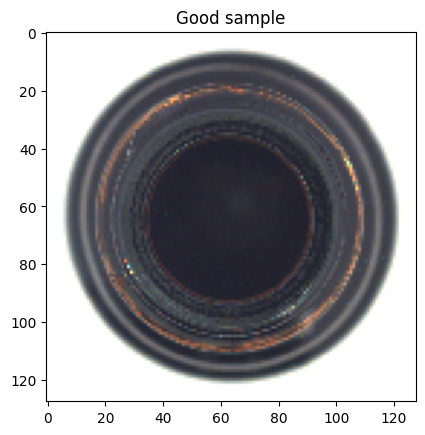

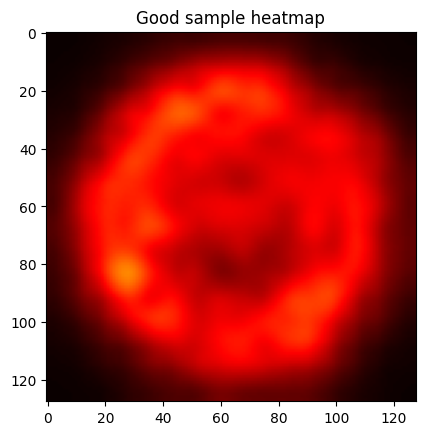

In [ ]:
plt.imshow(good_sample[0])
plt.title("Good sample")
plt.show()
plt.imshow(good_heatmap, cmap="hot", vmin=0, vmax=30)
plt.title("Good sample heatmap")
plt.show()

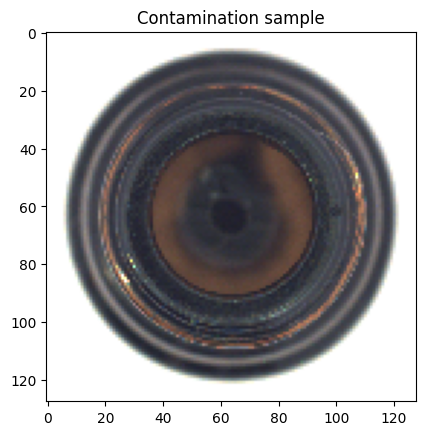

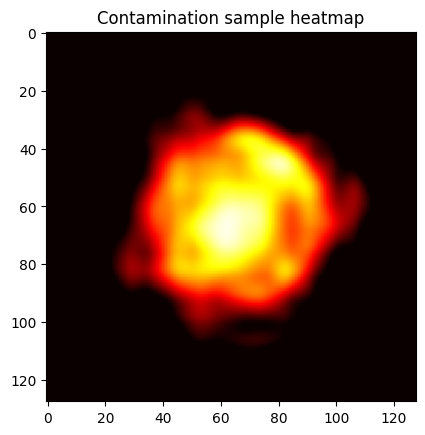

In [ ]:
plt.imshow(contamination_sample[0])
plt.title("Contamination sample")
plt.show()
baseline = np.percentile(good_heatmap, 90)
plt.imshow(contamination_heatmap, cmap="hot", vmin=baseline, vmax=30)
plt.title("Contamination sample heatmap")
plt.show()

In [ ]:
#Saving the results

with open("patchcore_memory_bank.pkl", "wb") as f:
  pickle.dump(memory_bank, f)

pathcore_results = {
    "backbone": "ResNet50",
    "feature_layer": feature_layer_name,
    "auroc": {k: float(v) for k, v in compute_auroc(all_categories_flat, scores_max).items()}
}
with open("patchcore_results.json", "w") as f:
    json.dump(pathcore_results, f, indent=2)